# 03 · Predicting the hotspots

**Question:** can we see next season's hotspots coming? Model at **district × ISO-week**,
target `log1p(DM tonnes)`, honest forward split **train 2012–16 / test 2017–18**, LightGBM.

Everything is benchmarked against a **climatology baseline** (each district-week's
historical mean), and each model is run **with and without** the ERA5 weather block —
an explicit ablation of how much weather actually helps.

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(ROOT)
if os.path.join(ROOT, 'src') not in sys.path: sys.path.insert(0, os.path.join(ROOT, 'src'))
import pandas as pd, numpy as np
from IPython.display import Image, display
pd.set_option('display.width', 140); pd.set_option('display.max_columns', 40)
print('project root:', ROOT)

project root: E:\New folder (3)


In [2]:
import fire_policy.predict as P
df = P.add_climatology(P.build_frame())
print(f'{len(df)} district-weeks | weather merged: {df.tmax_mean.notna().any()}')

2838 district-weeks | weather merged: True


### Baseline + four models (with / without weather)

In [3]:
base = P.eval_baseline(df)
_, _, m_b0, _ = P.train_eval(df, P.BASE_NO_WX, 'structural  (B, no weather)')
mb, te_b, m_b, _ = P.train_eval(df, P.BASE_FEATURES, 'structural  (B, +weather)')
_, _, m_a0, _ = P.train_eval(df, P.LAG_NO_WX,  'operational (A, no weather)')
ma, te_a, m_a, fa = P.train_eval(df, P.LAG_FEATURES, 'operational (A, +weather)')
cols=['model','RMSE_log','R2_log','Spearman','ROC_AUC_top10pct','Precision@k']
display(pd.DataFrame([base,m_b0,m_b,m_a0,m_a])[cols].round(3))

,model,RMSE_log,R2_log,Spearman,ROC_AUC_top10pct,Precision@k
0,climatology,1.458,0.820,0.919,0.986,0.829
1,"structural (B, no weather)",1.501,0.810,0.910,0.986,0.841
2,"structural (B, +weather)",1.821,0.720,0.873,0.959,0.683
3,"operational (A, no weather)",1.089,0.900,0.955,0.988,0.829
4,"operational (A, +weather)",1.066,0.904,0.957,0.985,0.829


### Marginal value of the weather block

In [4]:
for lbl, mw, m0 in [('Structural (B)', m_b, m_b0), ('Operational (A)', m_a, m_a0)]:
    print(f"{lbl:16s} dR2={mw['R2_log']-m0['R2_log']:+.3f}  "
          f"dSpearman={mw['Spearman']-m0['Spearman']:+.3f}  "
          f"dRMSE={mw['RMSE_log']-m0['RMSE_log']:+.3f}")

Structural (B)   dR2=-0.090  dSpearman=-0.038  dRMSE=+0.320
Operational (A)  dR2=+0.004  dSpearman=+0.002  dRMSE=-0.023


**Weather barely moves the operational model (+0.004 R²) and *hurts* the structural
one (−0.09 R²).** The signal is persistence + calendar, not weather.

### Predicted vs actual, and what drives the forecast

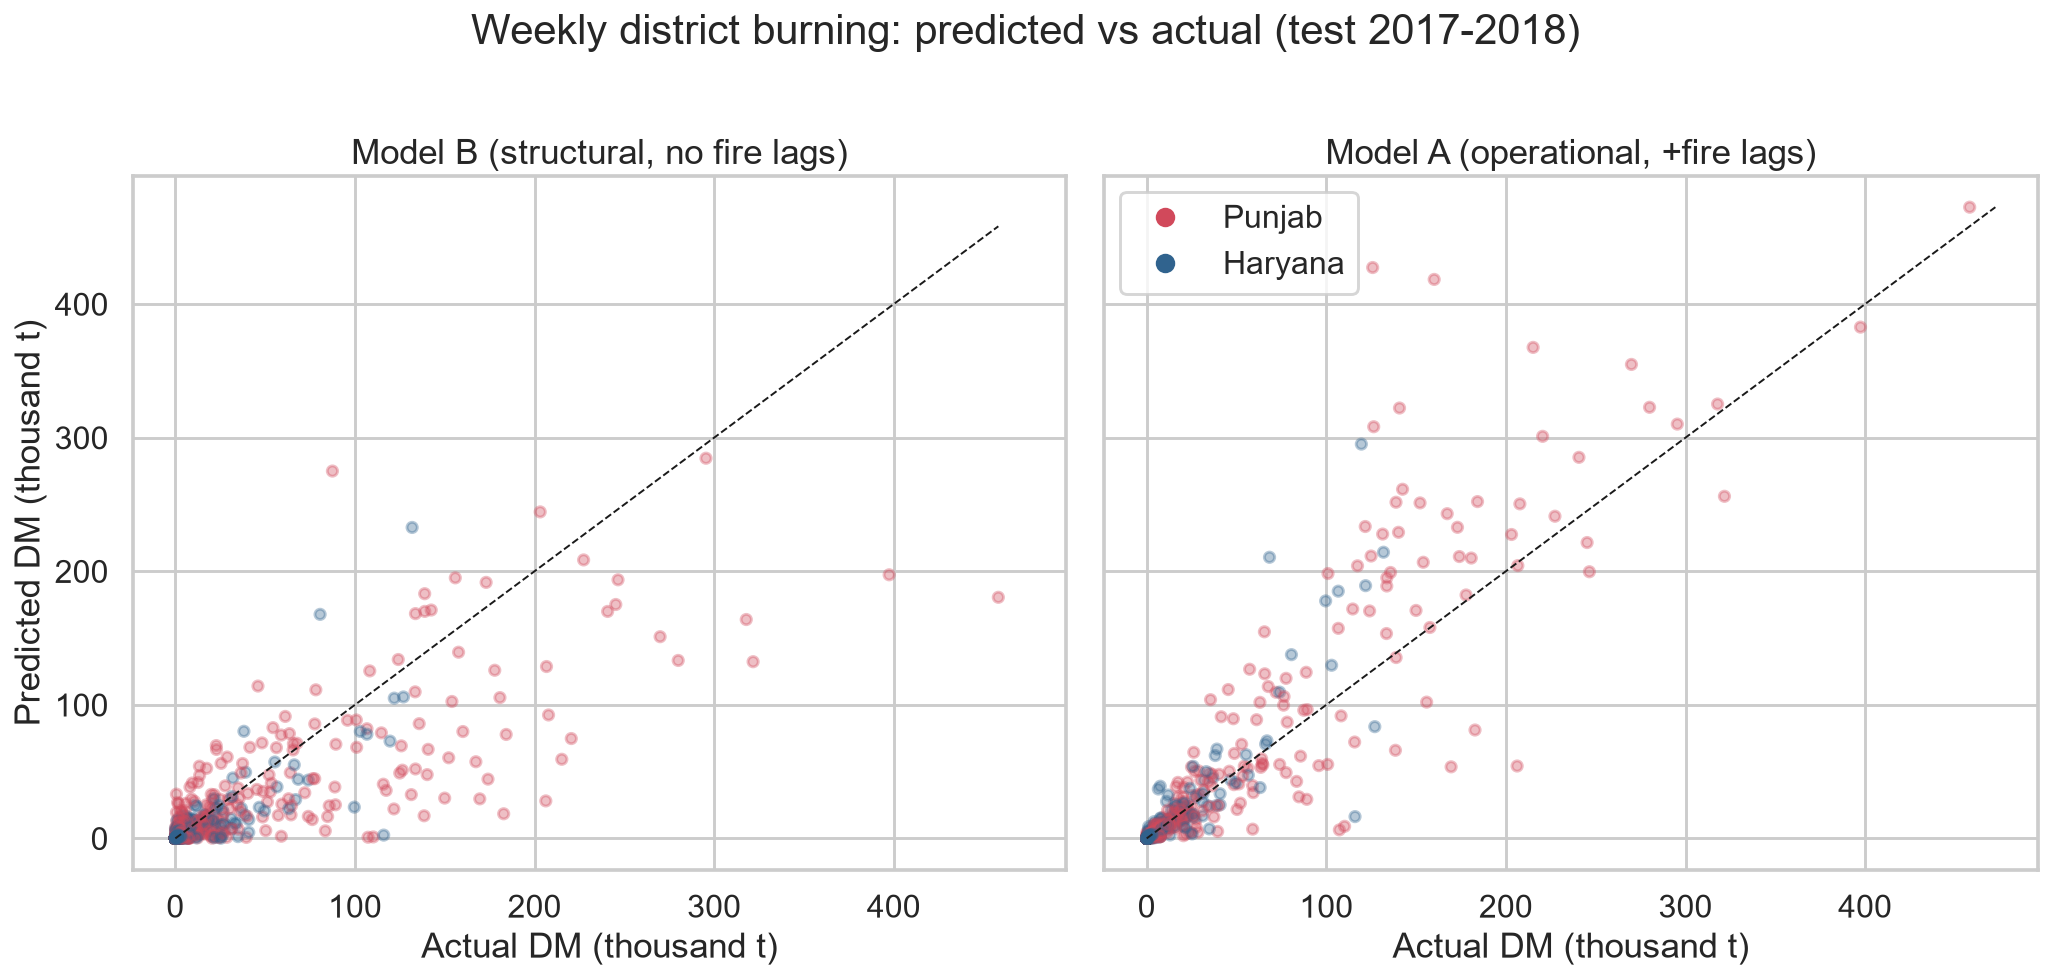

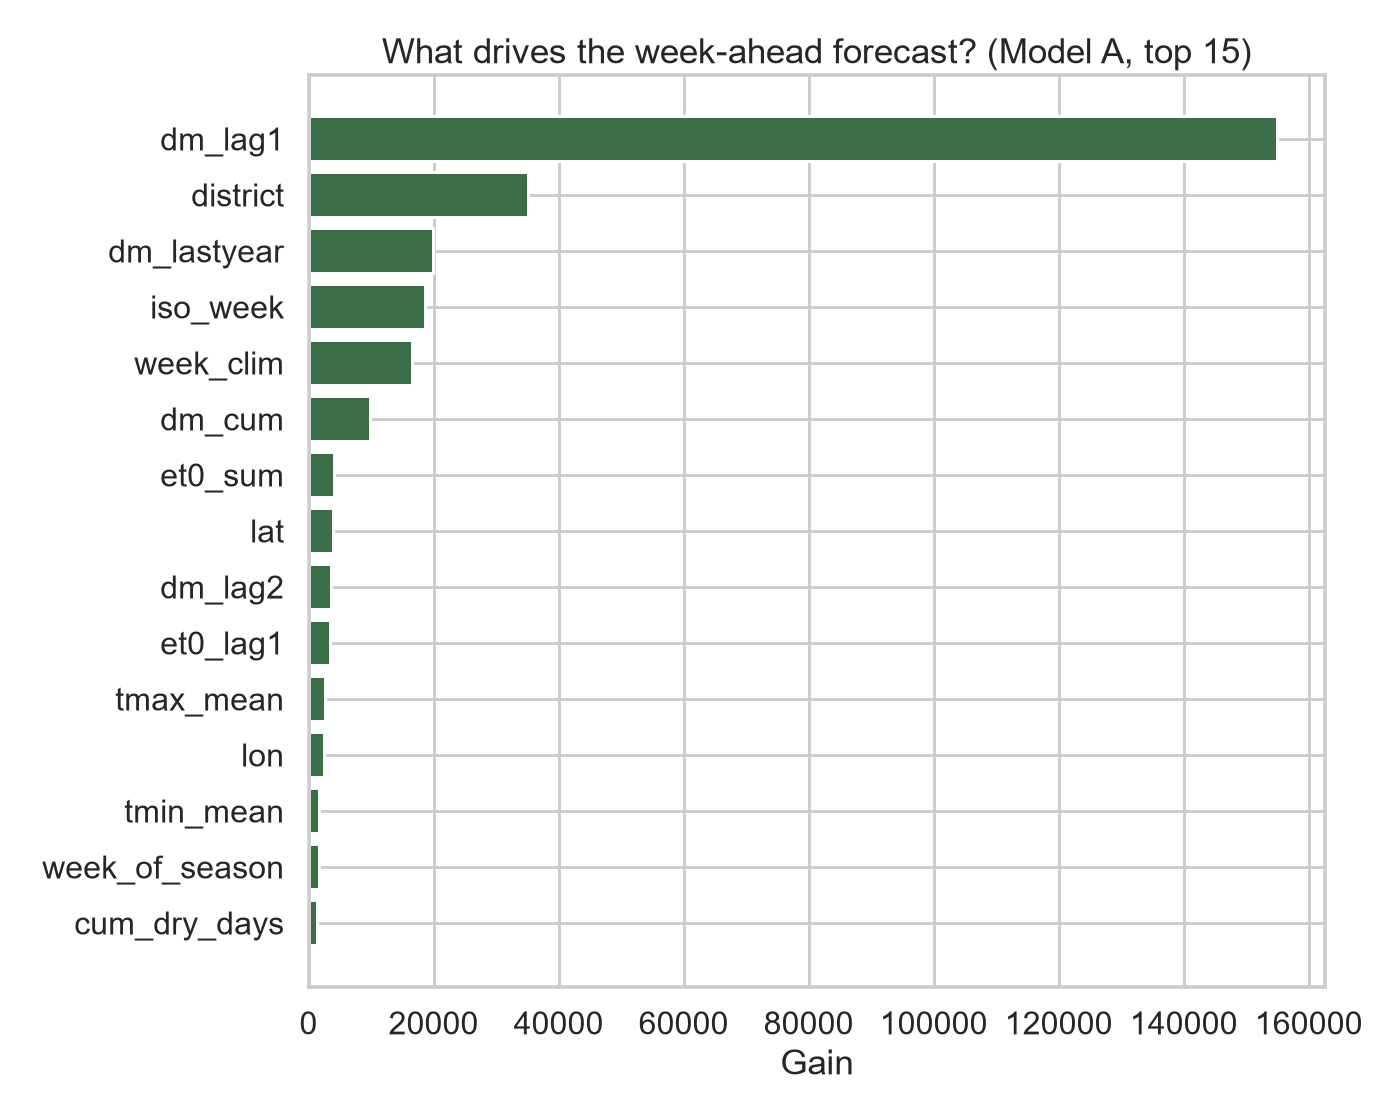

In [5]:
for _p in ['reports/figures/05_pred_vs_actual.png', 'reports/figures/06_feature_importance.png']:
    display(Image(filename=_p))

`dm_lag1` (last week's burning) alone is ~54% of the model's gain; the 8 weather features together are ~3%.

### Early-warning check — does it light up the right district-weeks?

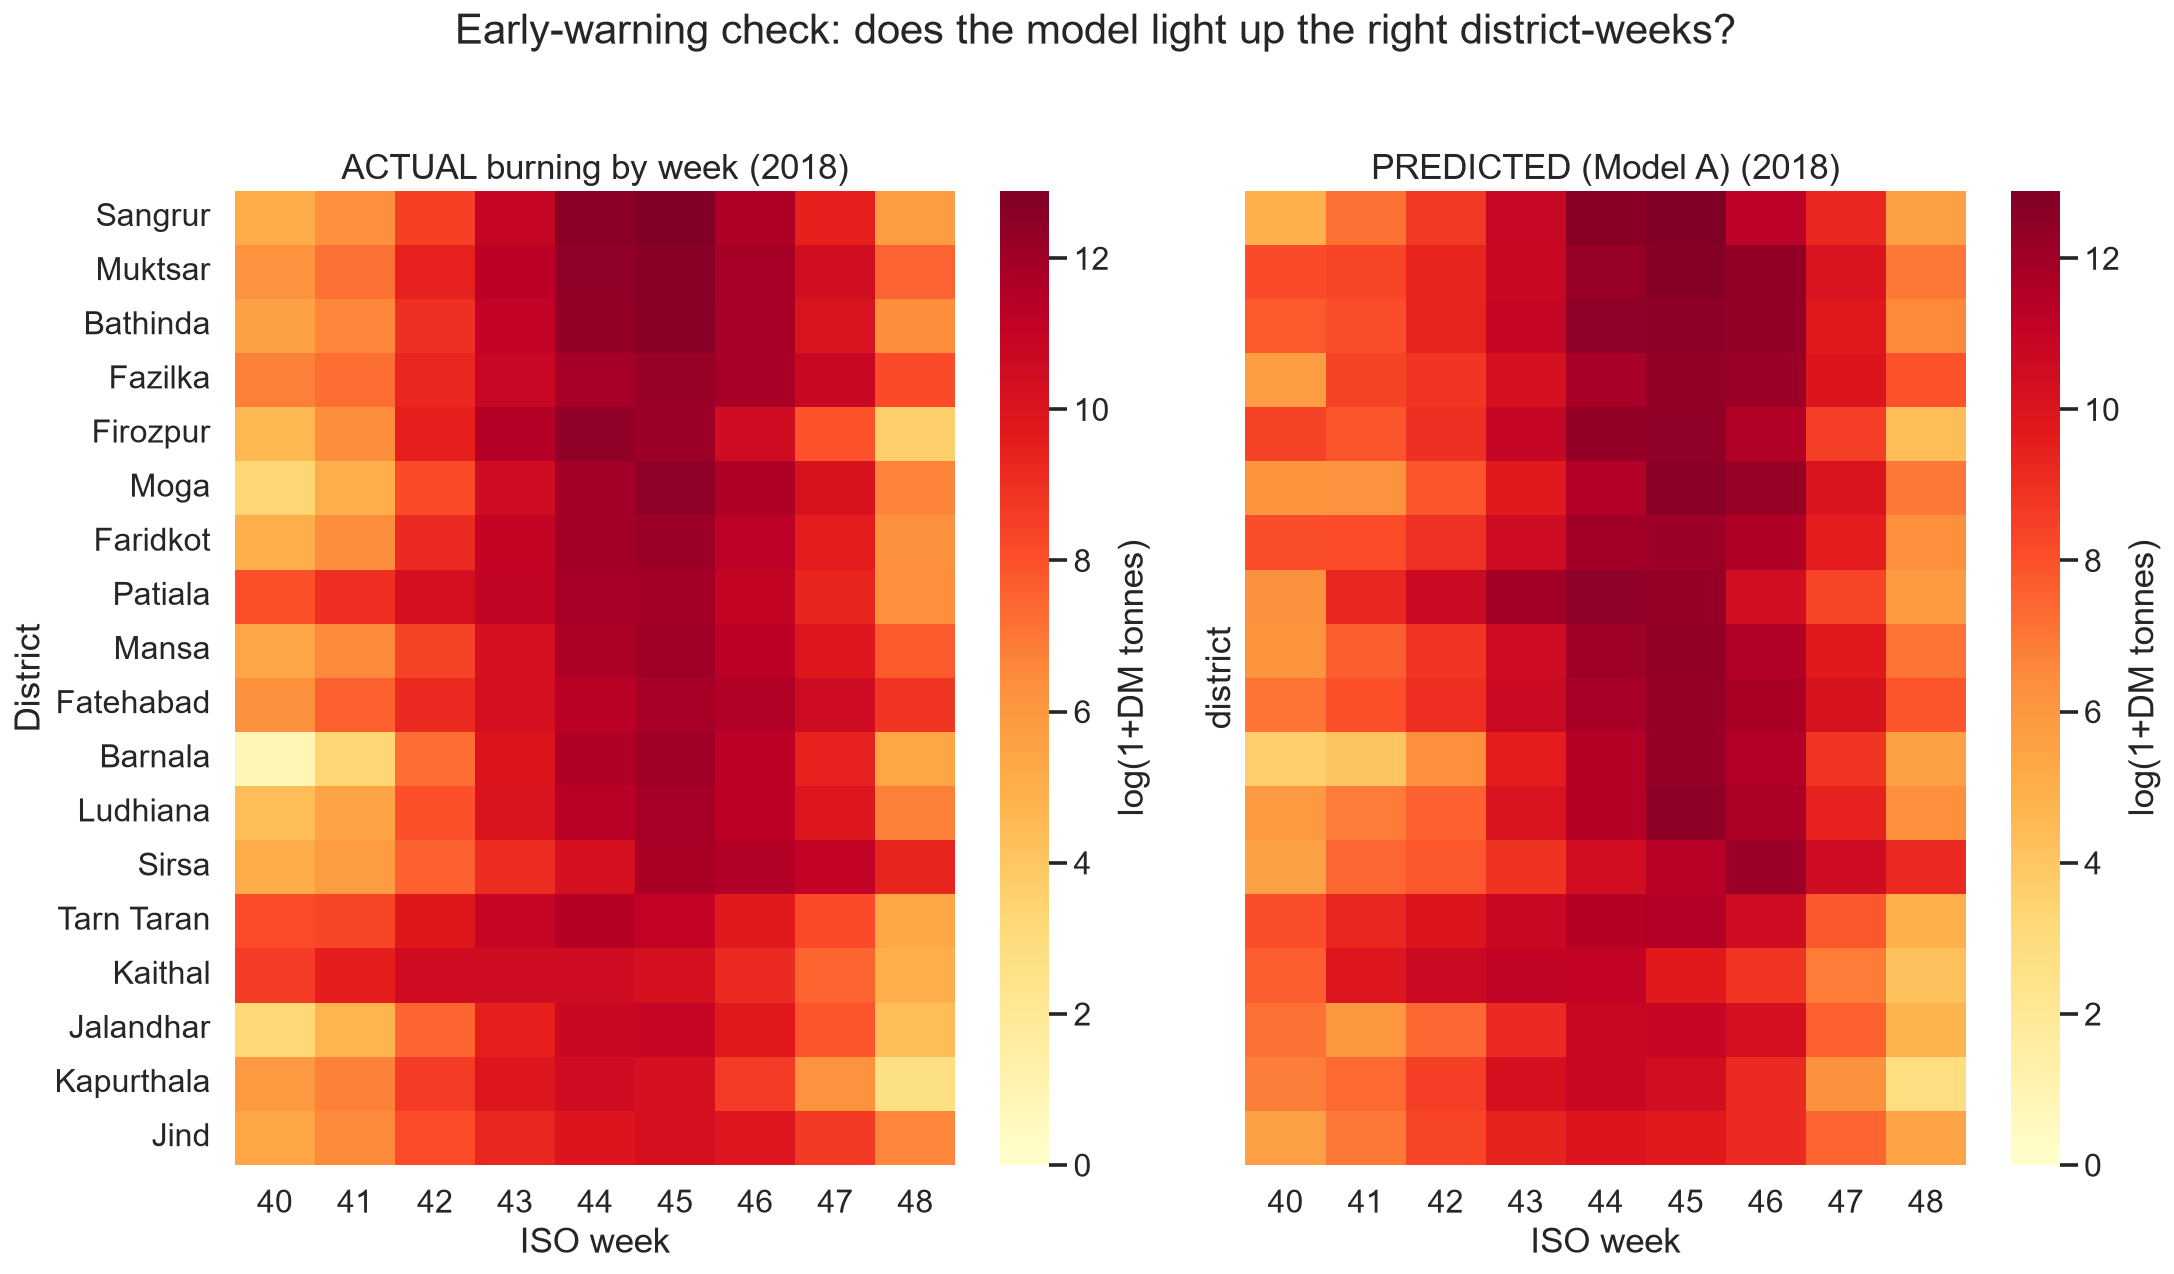

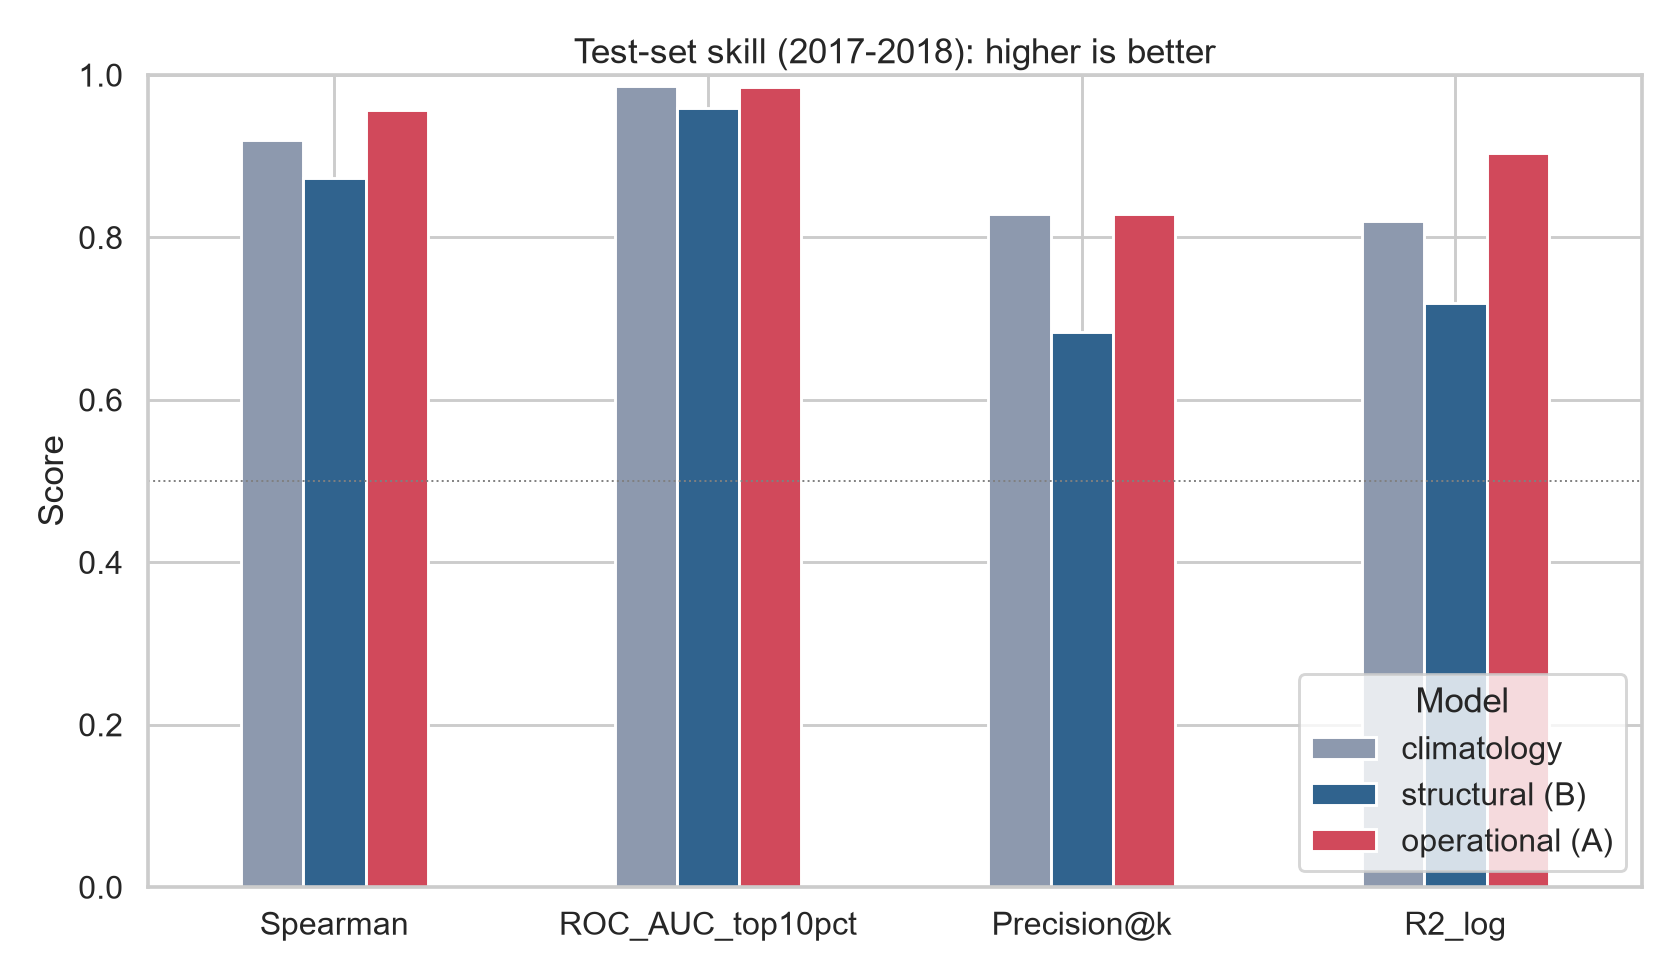

In [6]:
for _p in ['reports/figures/07_earlywarning_heatmap.png', 'reports/figures/08_model_skill.png']:
    display(Image(filename=_p))

**Takeaway:** hotspots are highly predictable a week ahead (R²≈0.90, ROC-AUC≈0.99),
and an operational dashboard needs last week's fire counts + the calendar — *not* a
weather feed.